In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import (r2_score, mean_absolute_error, mean_squared_error)
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv(r'C:\Users\sai\Desktop\Student_Performance\StudentsPerformance.csv')

In [3]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [4]:
df.shape

(1000, 8)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [6]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

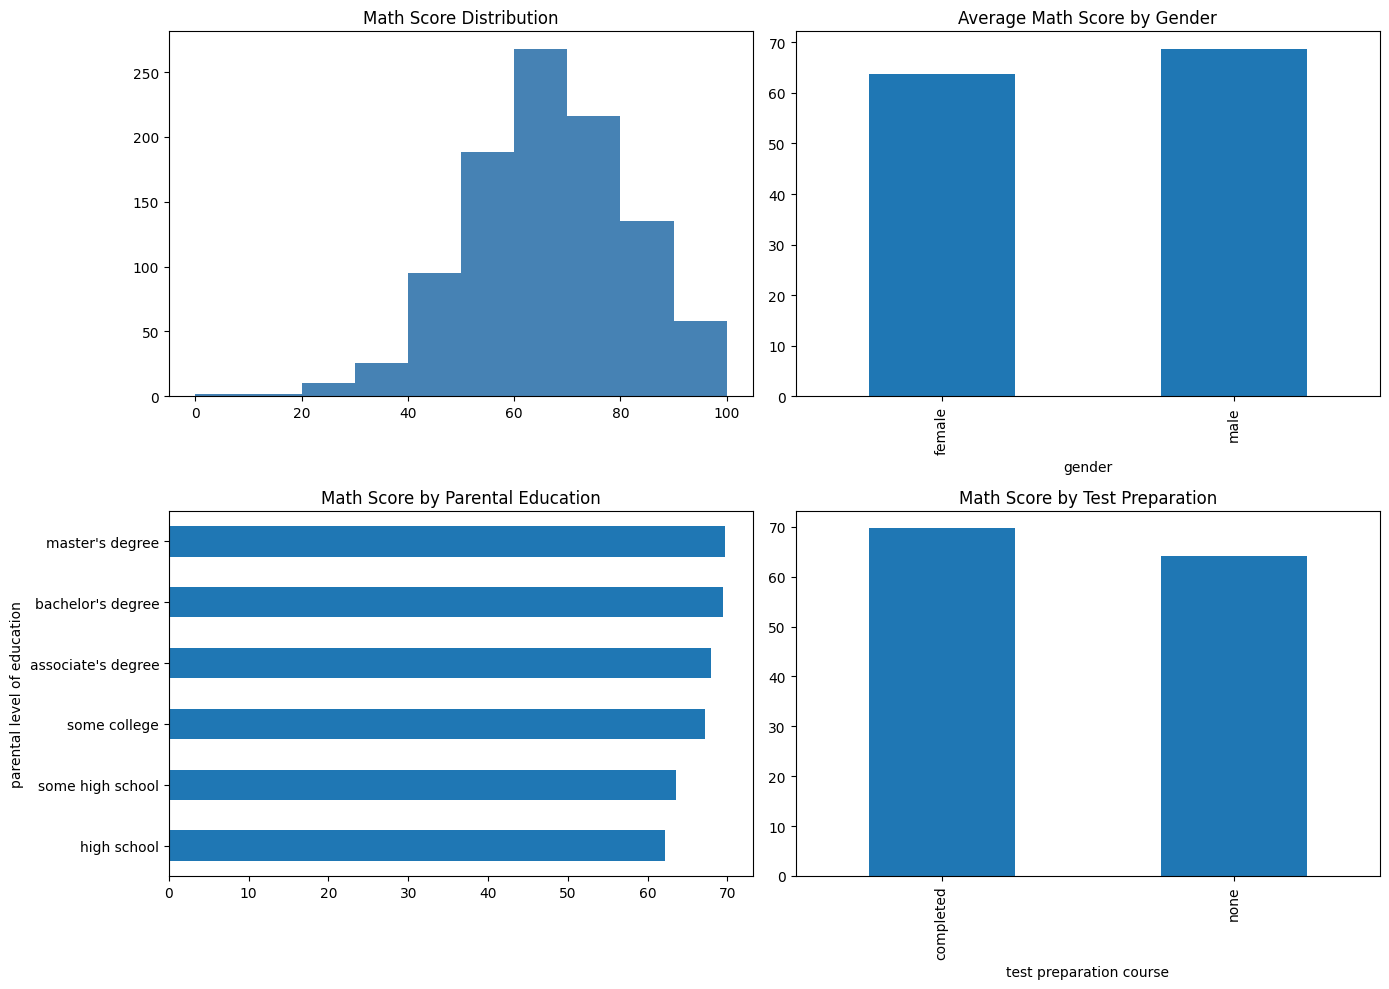

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes[0,0].hist(df['math score'],color = 'steelblue')
axes[0,0].set_title('Math Score Distribution')
df.groupby('gender')['math score'].mean().plot(kind='bar',ax = axes[0,1])
axes[0,1].set_title('Average Math Score by Gender')
df.groupby('parental level of education')['math score'].mean().sort_values().plot(kind='barh',ax = axes[1,0])
axes[1,0].set_title('Math Score by Parental Education')
df.groupby('test preparation course')['math score'].mean().plot(kind='bar', ax=axes[1,1])
axes[1,1].set_title('Math Score by Test Preparation')
plt.tight_layout()
plt.show()

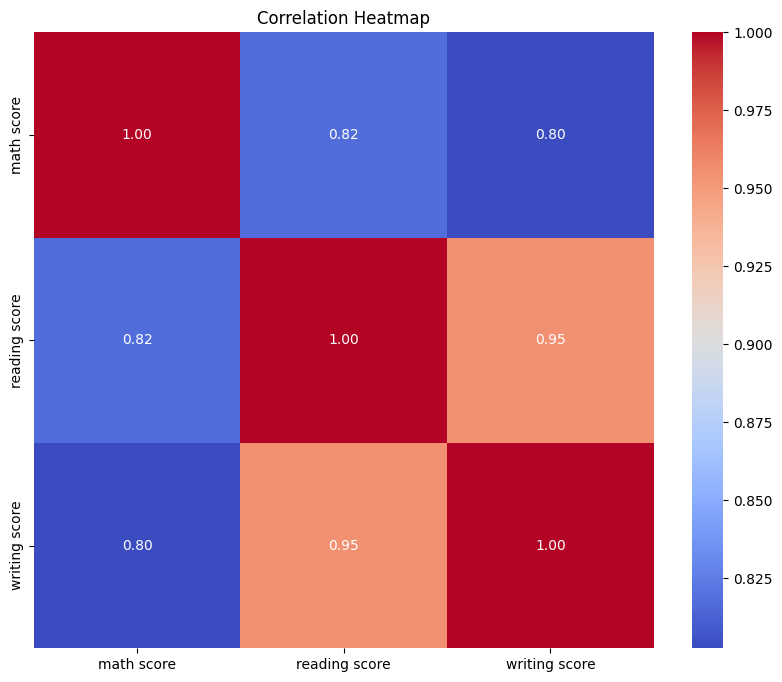

In [8]:
plt.figure(figsize = (10,8))
sns.heatmap(
    df.corr(numeric_only = True),
    annot = True,
    cmap = 'coolwarm',
    fmt = '.2f')
plt.title('Correlation Heatmap')
plt.show()

In [9]:
label_encoders={}
categorical_cols=[
    'gender',
    'race/ethnicity',
    'parental level of education',
    'lunch',
    'test preparation course'
]
for column in categorical_cols:
    le = LabelEncoder()
    df[column] = le.fit_transform(df[column])
    label_encoders[column] = le

In [10]:
df['avg_score'] = (df['reading score'] + df['writing score'])/2
df['score_gap'] = df['reading score'] - df['writing score']

In [11]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,avg_score,score_gap
0,0,1,1,1,1,72,72,74,73.0,-2
1,0,2,4,1,0,69,90,88,89.0,2
2,0,1,3,1,1,90,95,93,94.0,2
3,1,0,0,0,1,47,57,44,50.5,13
4,1,2,4,1,1,76,78,75,76.5,3


In [12]:
X = df.drop(['math score'],axis = 1)
y = df['math score']

In [13]:
X.shape

(1000, 9)

In [14]:
y.shape

(1000,)

In [15]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2 , random_state = 42) 

In [16]:
X_train.shape

(800, 9)

In [17]:
X_test.shape

(200, 9)

In [18]:
models = {
    'Linear Regression' : LinearRegression() ,
    'Decision Tree' : DecisionTreeRegressor(random_state = 42) ,
    'Random Forest' : RandomForestRegressor(n_estimators = 100, random_state = 42)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    r2 = r2_score(y_test , y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    results[name] = {'r2': r2, 'mae': mae, 'rmse': rmse}

    print(f"{name}: R2={r2*100:.2f}% | MAE={mae:.2f} | RMSE={rmse:.2f}")

Linear Regression: R2=88.38% | MAE=4.13 | RMSE=5.32
Decision Tree: R2=72.07% | MAE=6.58 | RMSE=8.24
Random Forest: R2=83.92% | MAE=4.81 | RMSE=6.26


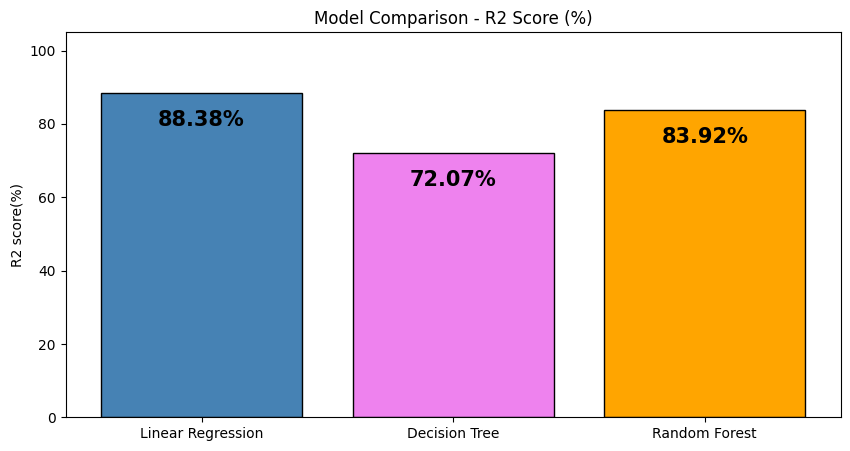

In [19]:
model_names  =  list(results.keys())
r2_scores = [results[m]['r2']*100 for m in model_names]

plt.figure(figsize = (10,5))
bars = plt.bar(model_names, r2_scores, color = ['steelblue','violet','orange'], edgecolor = 'black')
plt.title("Model Comparison - R2 Score (%)")
plt.ylabel("R2 score(%)")
plt.ylim(0,105)

for bar, score in zip(bars, r2_scores):
    plt.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + -9,
            f'{score:.2f}%',
            ha = 'center',
            fontsize = 15,
            fontweight = 'bold')

plt.show()

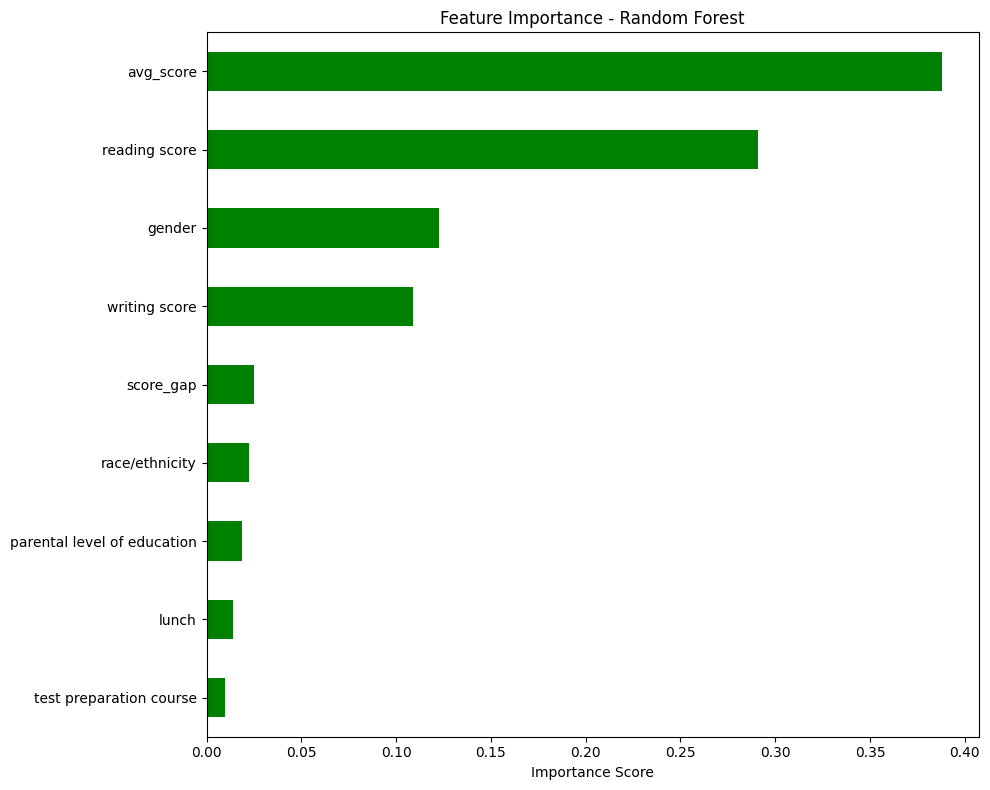

In [20]:
rf_model = models['Random Forest']
importance = pd.Series(rf_model.feature_importances_, index = X.columns)
importance.sort_values().plot(kind = 'barh', figsize=(10,8), color = 'green')
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [21]:
from sklearn.metrics import r2_score

In [22]:
best_model = models['Linear Regression']
y_pred_final = best_model.predict(X_test)
score = r2_score(y_test , y_pred_final)
mae = mean_absolute_error(y_test, y_pred_final)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_final))

print("Best Model: Linear Regression")
print(f"{name}: R2={score*100:.2f}% | MAE={mae:.2f} | RMSE={rmse:.2f}")

Best Model: Linear Regression
Random Forest: R2=88.38% | MAE=4.13 | RMSE=5.32


In [23]:
import joblib
joblib.dump(best_model, 'student_model.pkl')
print("🎉Model Saved🎉")

🎉Model Saved🎉
